<a href="https://colab.research.google.com/github/SimoneZangla/SimoZ/blob/Materiale/RichiesteAPI_PHP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Richieste API in PHP**

**Libreria**

In [ ]:
require_once 'Requests-develop/src/Autoload.php'; //carica il file di autoload della libreria Requests.
WpOrg\Requests\Autoload::register(); //registra l'autoload, permettendo di usare la classe Requests senza dover includere ogni file manualmente.

# Effettua una richiesta GET

$response = \WpOrg\Requests\Requests::get('https://api.github.com/events');

"$response" é ora un oggetto WpOrg\Requests\Response . Gli oggetti Response sono quelli con cui lavorerai ogni volta che vorrai recuperare dati dalla tua richiesta.

**Utilizzo dell'oggetto risposta**

In [ ]:
var_dump($response->body);
// string(42865) "[{"id":"15624773365","type":"PushEvent","actor":{...

**Intestazioni personalizzate**

In [ ]:
$response = \WpOrg\Requests\Requests::get('https://api.github.com/events', array('X-Requests' => 'Is Awesome!'));

Se vuoi aggiungere intestazioni personalizzate alla richiesta, passale semplicemente come array associativo come secondo parametro.

# Effettua una richiesta POST

Effettuare una richiesta POST è molto simile a effettuare una richiesta GET:

In [ ]:
$response = \WpOrg\Requests\Requests::post('https://httpbin.org/post');

Probabilmente vorrai anche passare alcuni dati. Puoi passare una stringa, un array o un oggetto (Requests usa http_build_query internamente) come terzo parametro (dopo l'URL e le intestazioni):

In [ ]:
$data = array('key1' => 'value1', 'key2' => 'value2');
$response = \WpOrg\Requests\Requests::post('https://httpbin.org/post', array(), $data);
var_dump($response->body);

Questo fornisce l'output:

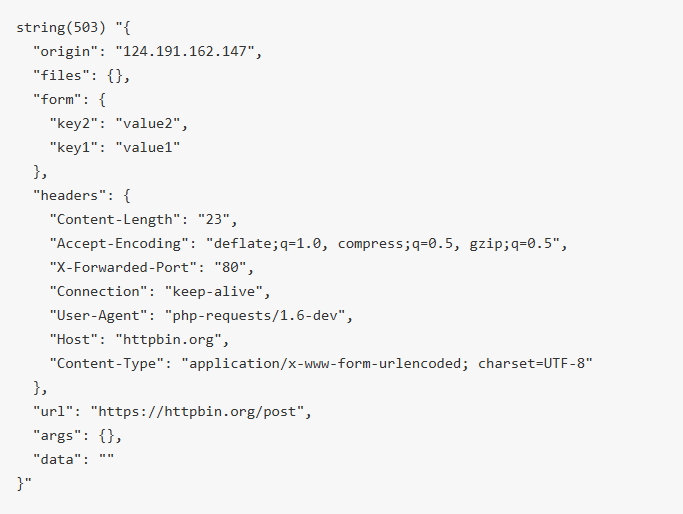

Per inviare dati grezzi, passa semplicemente una stringa. Probabilmente vorrai anche impostare l'intestazione Content-Type per assicurarti che il server remoto sappia cosa gli stai inviando:

In [ ]:
$url = 'https://api.github.com/some/endpoint';
$headers = array('Content-Type' => 'application/json');
$data = array('some' => 'data');
$response = \WpOrg\Requests\Requests::post($url, $headers, json_encode($data));

Nota che se non specifichi manualmente un'intestazione Content-Type, Requests ha un comportamento indefinito per l'intestazione. Può essere impostato su vari valori a seconda del percorso di esecuzione interno, quindi è consigliabile impostarlo esplicitamente se necessario.

# Codici di stato

L'oggetto Risposta fornisce anche accesso al codice di stato:

In [ ]:
var_dump($response->status_code);
// int(200)

Puoi anche controllare facilmente se questo codice di stato è un codice di successo o se è un errore:

In [ ]:
var_dump($response->success);
// bool(true)

# Intestazioni di risposta

Possiamo anche catturare le intestazioni abbastanza facilmente:

In [ ]:
var_dump($response->headers['Date']);
// string(29) "Thu, 09 Feb 2021 15:22:06 GMT"

Si noti che questa operazione non distingue tra maiuscole e minuscole, quindi i seguenti sono tutti equivalenti:

In [ ]:
$response->headers['Date']
$response->headers['date']
$response->headers['DATE']
$response->headers['dAtE']

Se non è impostata un'intestazione, questo darà null. Puoi anche controllare con:

In [ ]:
isset($response->headers['date'])

# **Esercitazione Geocoding**

Implementare un’applicazione web con l’utilizzo della libreria Requests di php, presentando all’utente un form per inserire dei dati (nome, cognome, città, indirizzo) e visualizzi una mappa centrata sulla città scelta.

Utilizzo POST nei form: https://www.w3schools.com/php/php_superglobals_post.asp

Conversione di un oggetto in un array JSON per stamparlo: https://www.w3schools.com/php/php_json.asp

Per realizzare la funzionalità richiesta sarà necessario utilizzare due web service:
- un API di Geocoding per trasformare l’indirizzo in coordinate;
- un API per la generazione di una mappa personalizzata con il marker centrato
sull’indirizzo inserito dall’utente.

A differenza dei web service restful utilizzati fino ad ora questi sono due servizi reali e quindi
prevedono una forma di autenticazione per poterli utilizzare.

# OpenCage Geocoding API

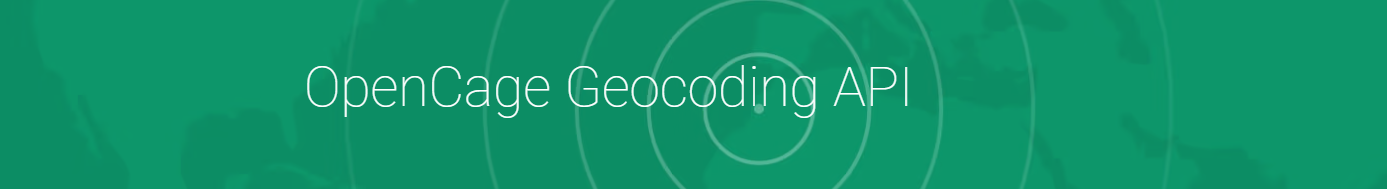

https://opencagedata.com/

1. Registrati https://opencagedata.com/users/sign_up
2. Accedi https://opencagedata.com/users/sign_in
3. Ottieni l’API KEY https://opencagedata.com/dashboard#

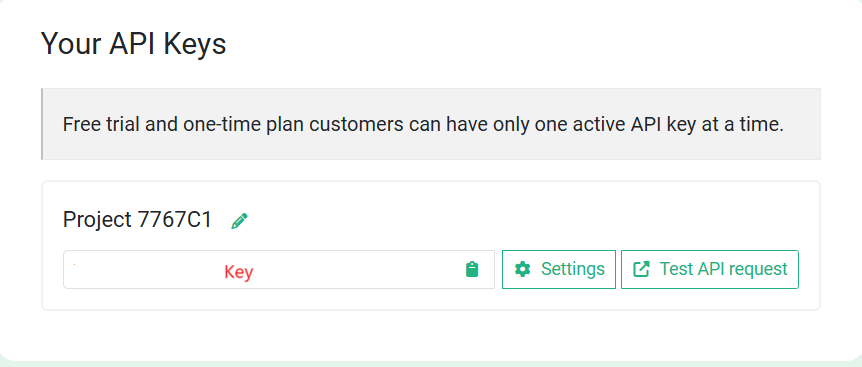

4. Controlla la documentazione dell’API https://opencagedata.com/api

In particolare:

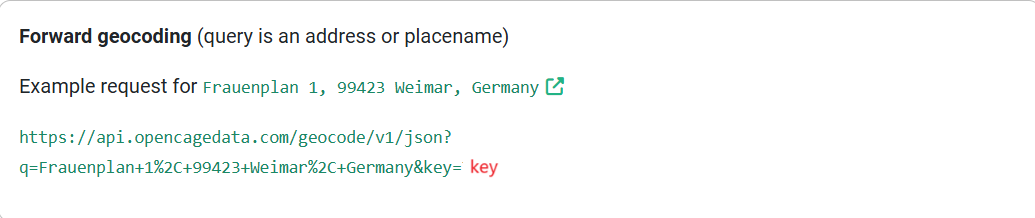

- Formato della richiesta (https://opencagedata.com/api#request)
- Parametri della richiesta (https://opencagedata.com/api#forward)
- Formato della risposta (https://opencagedata.com/api#response)

5. Prova la demo https://opencagedata.com/geosearch/demo